In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import pickle
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the model
with open('lightgbm_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [3]:
# Read the CSV file into a DataFrame
df = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV/Merged59.csv')

In [4]:
# Grouping
DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']



def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3860\387110630.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Label'].replace(DDoS,'DDoS',inplace=True)


In [5]:
# Preprocessing
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

data_clean = df.drop(columns=['fin_count', 'rst_count', 'Tot size', 'syn_count', 'ack_count', 'Std', 'Header_Length'])

In [6]:
columns_name = data_clean.drop(columns=['Label']).columns

In [7]:
# Create test data
X_test = data_clean.drop(columns=['Label'])
Y_test = data_clean['Label']

In [8]:
# for i in range(50):
#     sample = X_test.iloc[[i]]  # Must be 2D
#     pred = model.predict(sample)[0]
#     actual = Y_test.iloc[i]

#     print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

rand = random.randint(0,len(X_test))
test_data = X_test.iloc[[rand]]

pred_label = model.predict(test_data)
print("Predicted class label:", pred_label)
real_label = Y_test.iloc[rand]
print("Real class label:", real_label)

Predicted class label: ['Mirai']
Real class label: DDoS


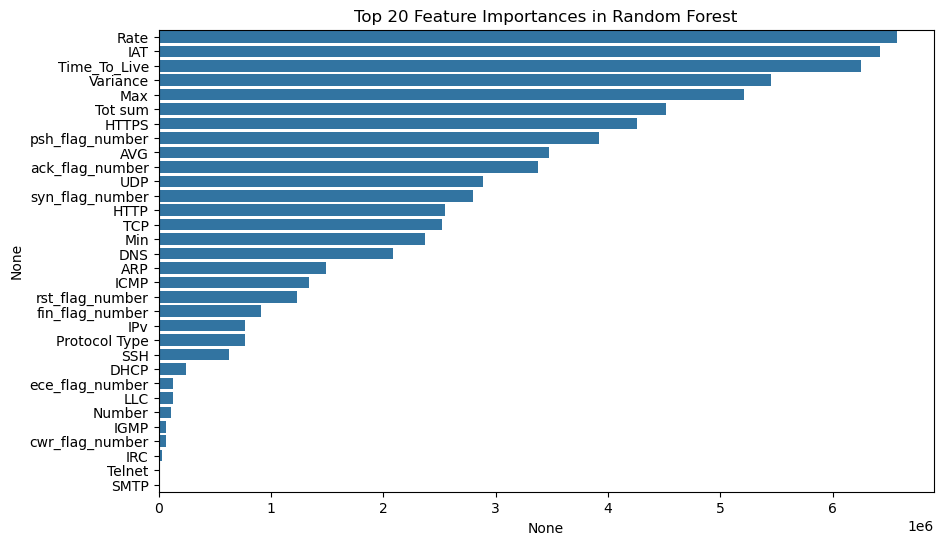

In [13]:
# Check feature importance
feat_importances = pd.Series(model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 20 Feature Importances in Random Forest")
plt.show()